In [1]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
from numpy import load

# Wczytanie plików

In [2]:
data = load('Data/synapsemnist3d.npz')
lst = data.files
print(f"Pliki {lst}")

Pliki ['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']


In [3]:
data['train_images'].shape

(1230, 28, 28, 28)

In [4]:
train_images = data['train_images']
train_labels = data['train_labels']
val_images = data['val_images']
val_labels = data['val_labels']
test_images = data['test_images']
test_labels = data['test_labels']

In [5]:
train_images

array([[[[220,  59, 101, ..., 199,  23, 193],
         [229, 223,  38, ...,  21, 159, 142],
         [241, 160,  28, ...,  13, 156, 133],
         ...,
         [ 37,  23,  29, ...,  27,  42,  81],
         [ 12,  35,  32, ...,  37, 164,  74],
         [ 17,  13,  26, ...,  51,  92,  47]],

        [[187, 193,  95, ...,  79,  61,  70],
         [ 65, 161,  25, ...,  27, 220, 144],
         [ 78, 192,  73, ...,  37, 205, 173],
         ...,
         [ 17,  20,  34, ...,  57,  45, 135],
         [ 42,  51,  25, ..., 184, 122, 193],
         [ 50,  36,  40, ..., 147, 139, 173]],

        [[185, 156, 154, ...,  15,  78,  93],
         [ 89, 136,  84, ...,  63, 156, 143],
         [ 66, 109, 124, ..., 125, 214,  98],
         ...,
         [ 43,  29,  16, ...,  31,  41, 143],
         [ 34,  24,  21, ..., 149, 229, 139],
         [124,  31,  20, ..., 162, 159, 171]],

        ...,

        [[101,  75,  95, ...,  66,  75,  52],
         [127, 180, 129, ..., 172, 122,  71],
         [154, 179

In [6]:
train_labels

array([[1],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]], shape=(1230, 1), dtype=uint8)

Text(0.5, 1.0, 'Klasy')

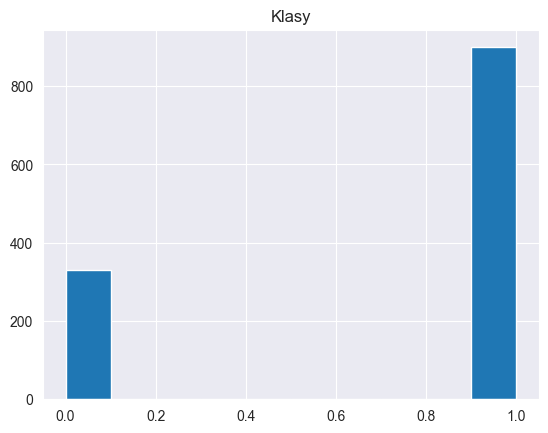

In [7]:
plt.hist(train_labels)
plt.title("Klasy")

# Wyświetlenie przykładowego obrazu

In [8]:
example_image = train_images[0]
example_label = train_labels[0]
example_image

array([[[220,  59, 101, ..., 199,  23, 193],
        [229, 223,  38, ...,  21, 159, 142],
        [241, 160,  28, ...,  13, 156, 133],
        ...,
        [ 37,  23,  29, ...,  27,  42,  81],
        [ 12,  35,  32, ...,  37, 164,  74],
        [ 17,  13,  26, ...,  51,  92,  47]],

       [[187, 193,  95, ...,  79,  61,  70],
        [ 65, 161,  25, ...,  27, 220, 144],
        [ 78, 192,  73, ...,  37, 205, 173],
        ...,
        [ 17,  20,  34, ...,  57,  45, 135],
        [ 42,  51,  25, ..., 184, 122, 193],
        [ 50,  36,  40, ..., 147, 139, 173]],

       [[185, 156, 154, ...,  15,  78,  93],
        [ 89, 136,  84, ...,  63, 156, 143],
        [ 66, 109, 124, ..., 125, 214,  98],
        ...,
        [ 43,  29,  16, ...,  31,  41, 143],
        [ 34,  24,  21, ..., 149, 229, 139],
        [124,  31,  20, ..., 162, 159, 171]],

       ...,

       [[101,  75,  95, ...,  66,  75,  52],
        [127, 180, 129, ..., 172, 122,  71],
        [154, 179, 156, ..., 252, 221, 199

## Wszystkie warstwy

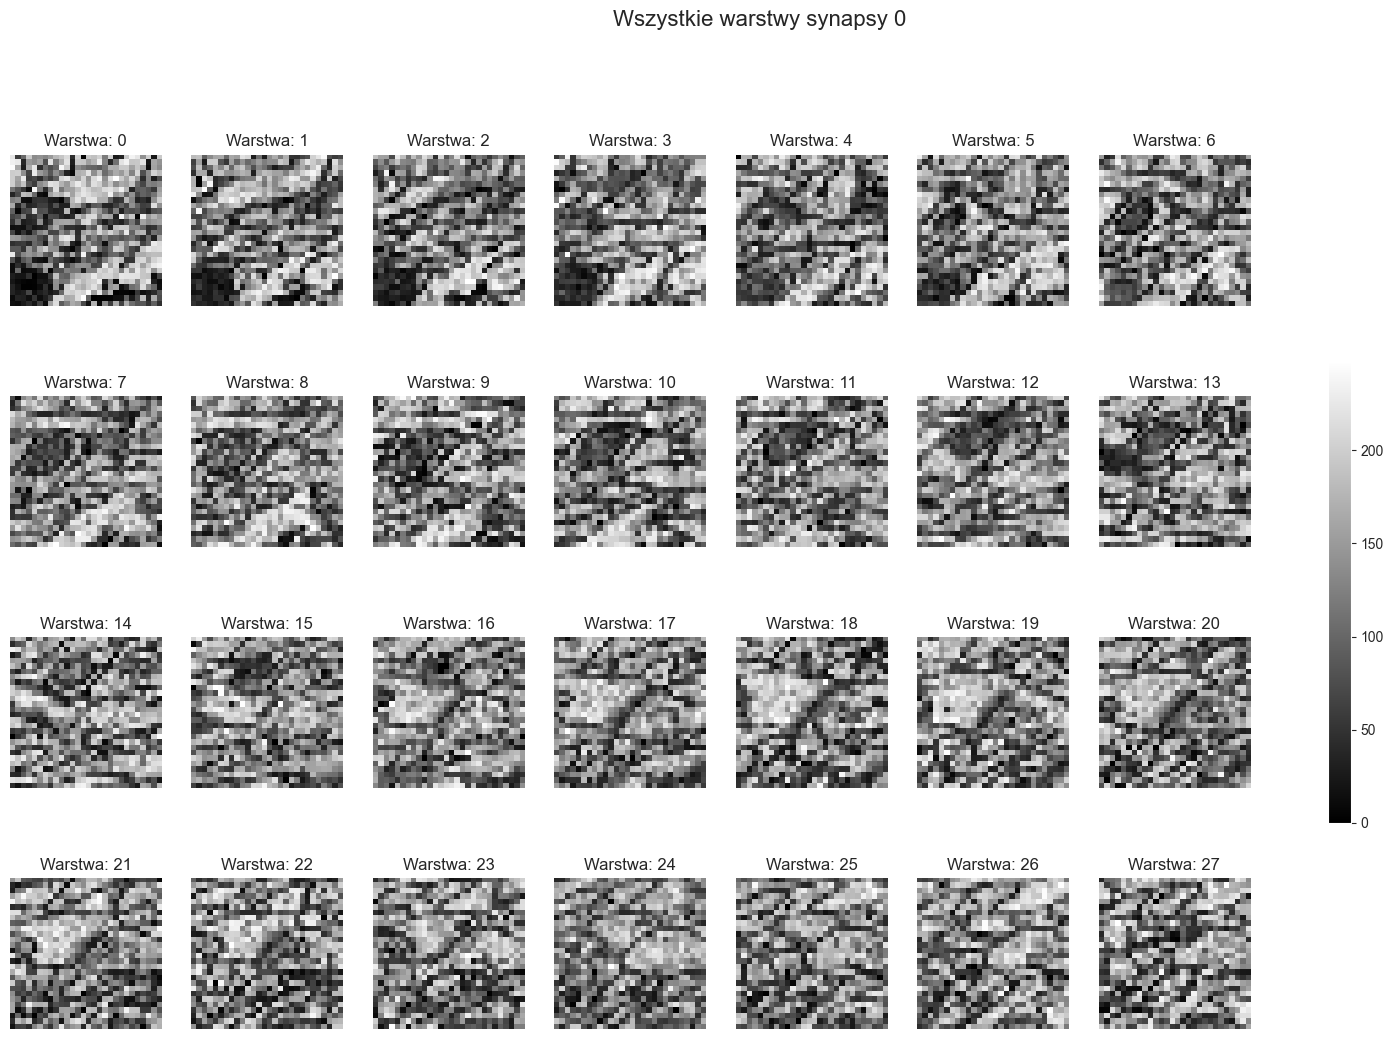

In [9]:
# jest 28 warstw więc robimy subploty
fig, axes = plt.subplots(4, 7, figsize=(20,12))

axes = axes.flatten()

for id in range(28):
    ax = axes[id]
    im = ax.imshow(example_image[id, :, :], cmap='gray')
    ax.set_title(f"Warstwa: {id}")
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5)
plt.suptitle(f"Wszystkie warstwy synapsy {0}", fontsize=16)
plt.show()

## Histogramy

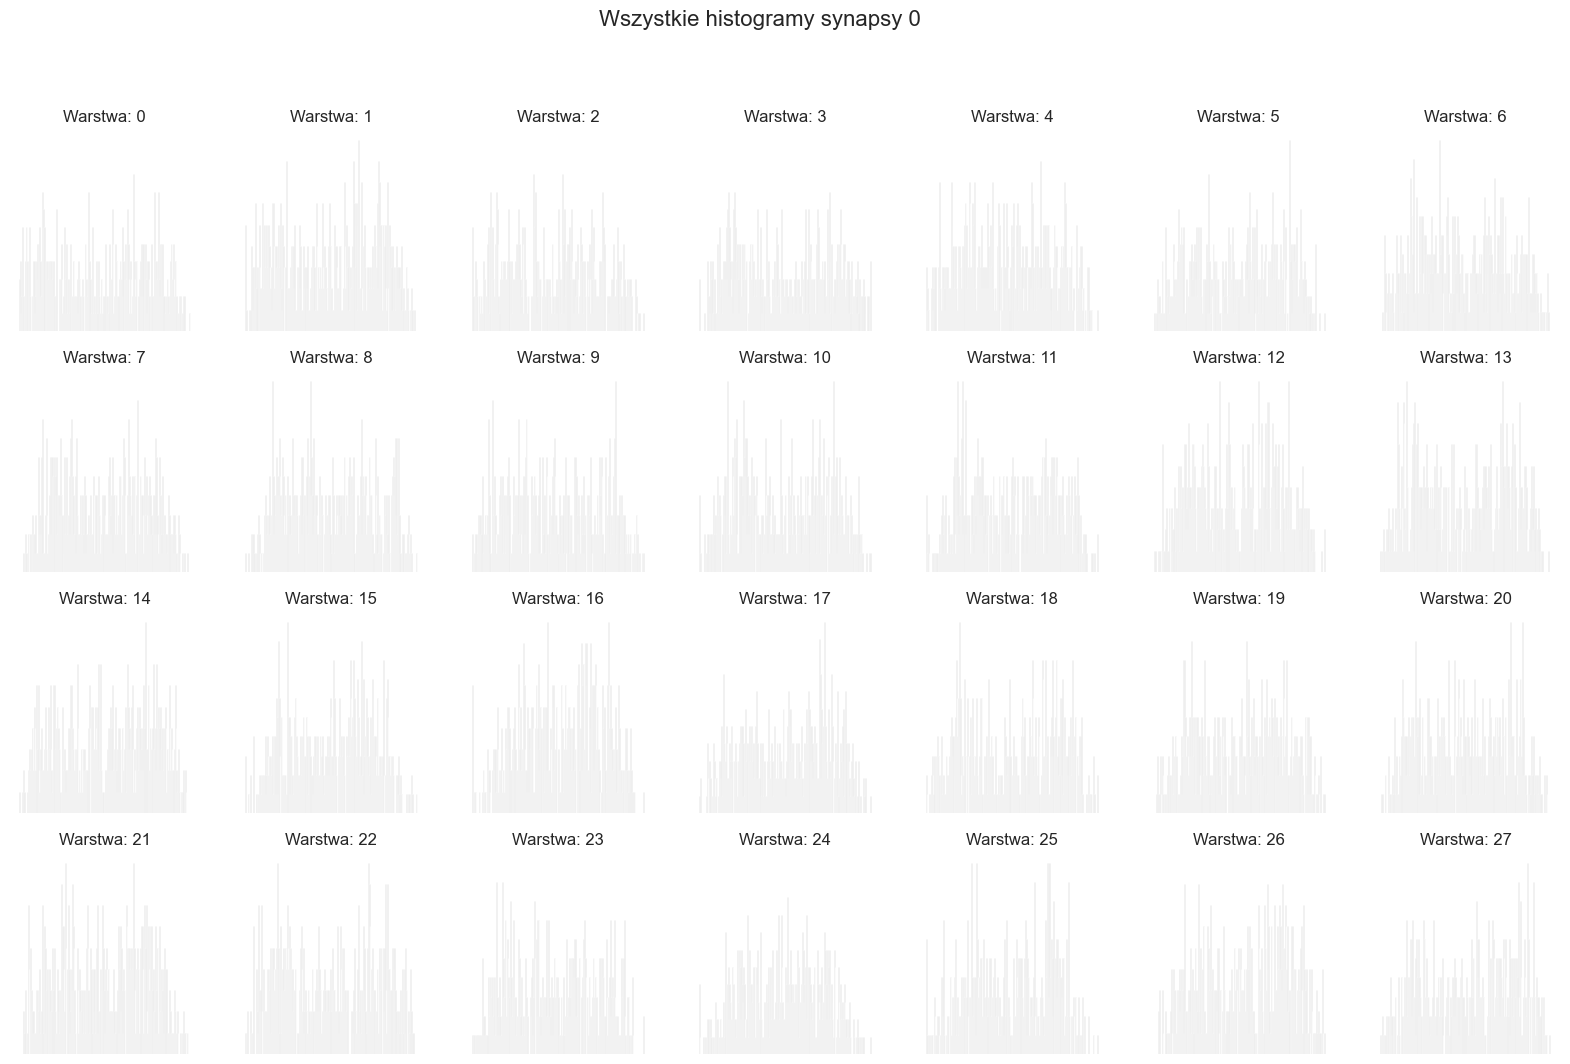

In [10]:
# jest 28 warstw więc robimy subploty
fig, axes = plt.subplots(4, 7, figsize=(20,12))

axes = axes.flatten()

for id in range(28):
    ax = axes[id]
    im = ax.hist(example_image[id, :, :].flatten(), bins=256, color='gray', alpha=0.7)
    ax.set_title(f"Warstwa: {id}")
    ax.axis("off")

plt.suptitle(f"Wszystkie histogramy synapsy {0}", fontsize=16)
plt.show()

# Zadanie
Sprawdzimy sobie który model najlepiej się sprawdzi do klasyfikacji zdjęć weźniemy pod uwagę:
- sieć neuronową
- pca
- svm

## Sieć neuronowa

### Wczytanie do dataloaderów

In [11]:
import tensorflow as tf
import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import torch.nn.functional as F

In [12]:
X_train = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(train_labels, dtype=torch.long)

X_val = torch.tensor(val_images, dtype=torch.float32).unsqueeze(1)
y_val = torch.tensor(val_labels, dtype=torch.long)

X_test = torch.tensor(test_images, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_labels, dtype=torch.long)


BATCH_SIZE = 32
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
train_loader

### Sieć neuronowa

In [14]:
import torch.nn as nn
import torch.nn.functional as F

class CNN_3D(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN_3D, self).__init__()

        self.conv1 = nn.Conv3d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm3d(32)

        self.conv2 = nn.Conv3d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(64)

        self.conv3 = nn.Conv3d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm3d(128)

        self.pool = nn.MaxPool3d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool3d((4, 4, 4))

        self.fc1 = nn.Linear(128 * 4 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)

        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model = CNN_3D(num_classes=2)

### Trening

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        labels = labels.squeeze().long()
        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            labels = labels.squeeze().long()
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()
            total_val += labels.size(0)

    epoch_train_loss = train_loss / total_train
    epoch_train_acc = (train_correct / total_train) * 100
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (val_correct / total_val) * 100

    print(f"Epoka [{epoch+1}/{num_epochs}]")
    print(f"Trening -> Strata: {epoch_train_loss:.4f}, Dokładność: {epoch_train_acc:.2f}%")
    print(f"Walidacja   -> Strata: {epoch_val_loss:.4f}, Dokładność: {epoch_val_acc:.2f}%")
    print("-" * 30)

Epoka [1/30]
Trening -> Strata: 1.0327, Dokładność: 68.21%
Walidacja   -> Strata: 0.9767, Dokładność: 72.88%
------------------------------
Epoka [2/30]
Trening -> Strata: 0.5437, Dokładność: 74.07%
Walidacja   -> Strata: 0.5959, Dokładność: 72.32%
------------------------------
Epoka [3/30]
Trening -> Strata: 0.5005, Dokładność: 76.99%
Walidacja   -> Strata: 0.7184, Dokładność: 73.45%
------------------------------
Epoka [4/30]
Trening -> Strata: 0.4468, Dokładność: 79.19%
Walidacja   -> Strata: 0.5454, Dokładność: 71.75%
------------------------------
Epoka [5/30]
Trening -> Strata: 0.4110, Dokładność: 80.81%
Walidacja   -> Strata: 0.5300, Dokładność: 76.27%
------------------------------
Epoka [6/30]
Trening -> Strata: 0.3097, Dokładność: 84.72%
Walidacja   -> Strata: 0.8748, Dokładność: 79.10%
------------------------------
Epoka [7/30]
Trening -> Strata: 0.2715, Dokładność: 89.43%
Walidacja   -> Strata: 0.7099, Dokładność: 77.97%
------------------------------
Epoka [8/30]
Trening

### Test

In [84]:
all_preds = []
all_true = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.view(-1).numpy())

### Statystyki i macierz pomyłek

Dokładność: 83.24%

Report Klasyfikacji:
              precision    recall  f1-score   support

           0       0.77      0.54      0.63        95
           1       0.85      0.94      0.89       257

    accuracy                           0.83       352
   macro avg       0.81      0.74      0.76       352
weighted avg       0.83      0.83      0.82       352



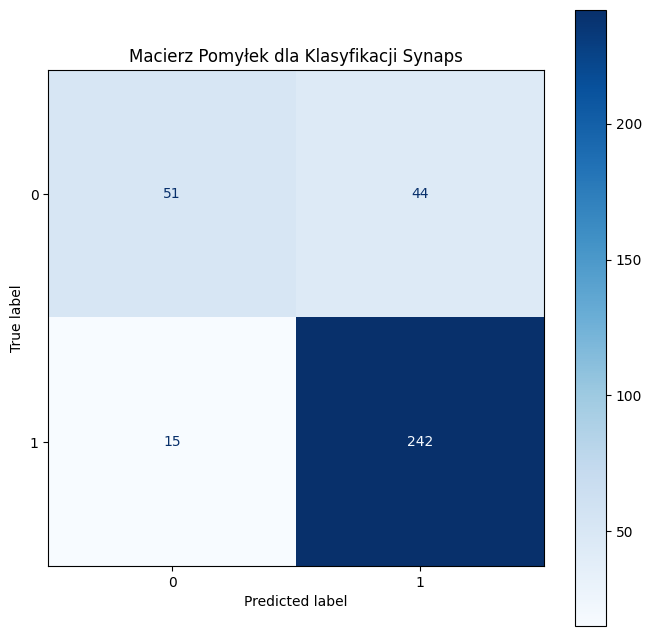

In [85]:
acc = accuracy_score(all_true, all_preds)
print(f"Dokładność: {acc:.2%}")
print("\nReport Klasyfikacji:")
print(classification_report(all_true, all_preds, target_names=['0', '1']))

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Macierz Pomyłek dla Klasyfikacji Synaps')
plt.show()

## PCA i SVM
Mega słaba metoda

In [74]:
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

### Przetworzenie danych

In [38]:
X_train = train_images.reshape(len(train_images), -1)
X_test = test_images.reshape(len(test_images), -1)

y_train = train_labels
y_test = test_labels

pca = PCA(n_components=0.99, whiten=True)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Liczba cech po PCA: {pca.n_components_}")

Liczba cech po PCA: 1200


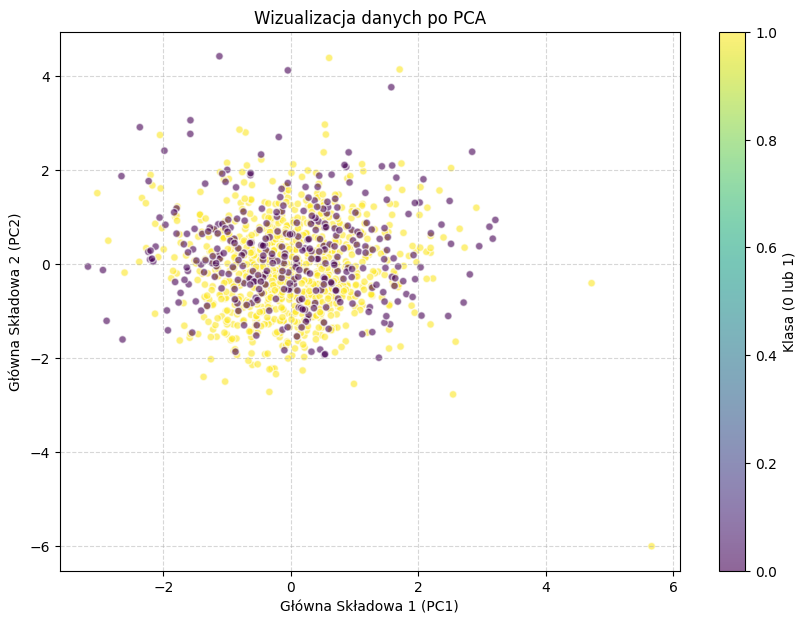

In [39]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap='viridis', alpha=0.6, edgecolors='w', s=30)

plt.colorbar(scatter, label='Klasa (0 lub 1)')
plt.xlabel(f'Główna Składowa 1 (PC1)')
plt.ylabel(f'Główna Składowa 2 (PC2)')
plt.title('Wizualizacja danych po PCA')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Predykcja i statystyki

C:\Users\jakub\Documents\GitHub\Medical Data Analysis\.venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Dokładność: 26.99%

Report Klasyfikacji:
              precision    recall  f1-score   support

           0       0.27      1.00      0.43        95
           1       0.00      0.00      0.00       257

    accuracy                           0.27       352
   macro avg       0.13      0.50      0.21       352
weighted avg       0.07      0.27      0.11       352



C:\Users\jakub\Documents\GitHub\Medical Data Analysis\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jakub\Documents\GitHub\Medical Data Analysis\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jakub\Documents\GitHub\Medical Data Analysis\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


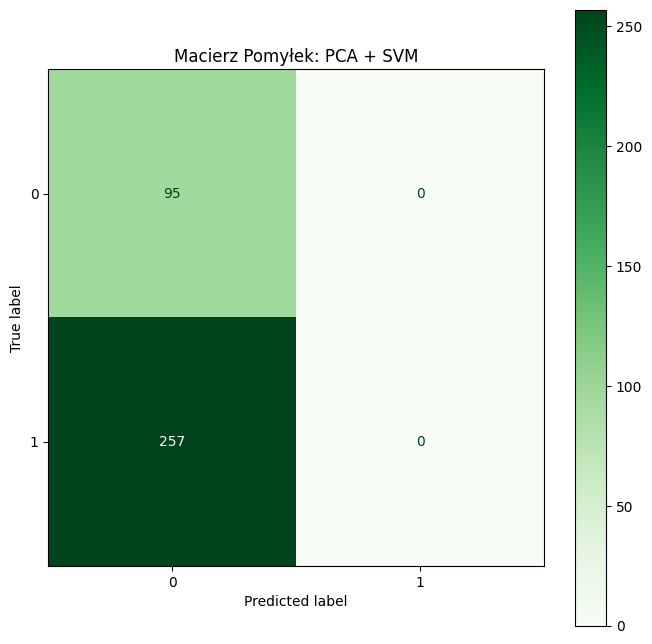

In [40]:
clf = SVC(kernel='rbf', class_weight='balanced')
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred)
print(f"Dokładność: {acc:.2%}")
print("\nReport Klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=['0', '1']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Greens', values_format='d')
plt.title('Macierz Pomyłek: PCA + SVM')
plt.show()

## LDA

### Przetworzenie danych

In [43]:
X_train = train_images.reshape(len(train_images), -1)
X_test = test_images.reshape(len(test_images), -1)

lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print(f"Liczba cech po LDA: {X_train_lda.shape[1]}")

C:\Users\jakub\Documents\GitHub\Medical Data Analysis\.venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Liczba cech po LDA: 1


### Wizualizacja danych

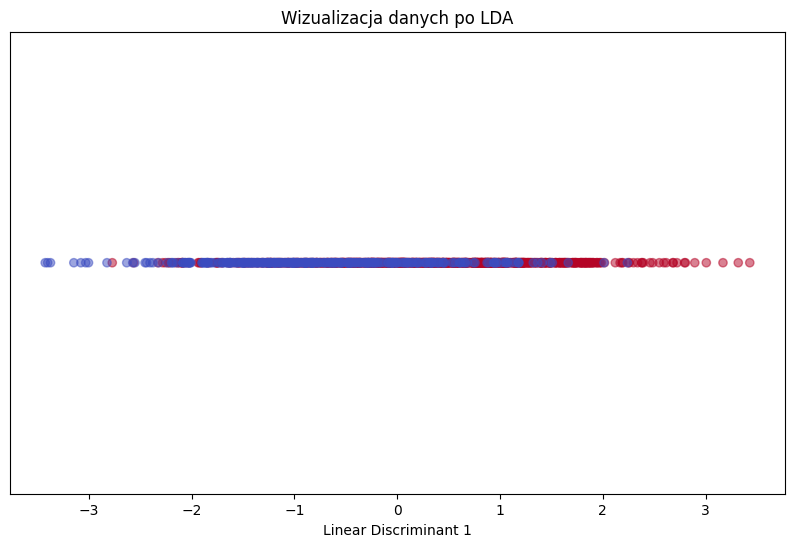

In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_lda, [0] * len(X_train_lda), c=y_train, cmap='coolwarm', alpha=0.5)
plt.title('Wizualizacja danych po LDA')
plt.xlabel('Linear Discriminant 1')
plt.yticks([])
plt.show()

### Predykcja i statystyki

Dokładność (LDA + SVM): 66.19%

Report Klasyfikacji:
              precision    recall  f1-score   support

           0       0.38      0.38      0.38        95
           1       0.77      0.77      0.77       257

    accuracy                           0.66       352
   macro avg       0.57      0.57      0.57       352
weighted avg       0.66      0.66      0.66       352



C:\Users\jakub\Documents\GitHub\Medical Data Analysis\.venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


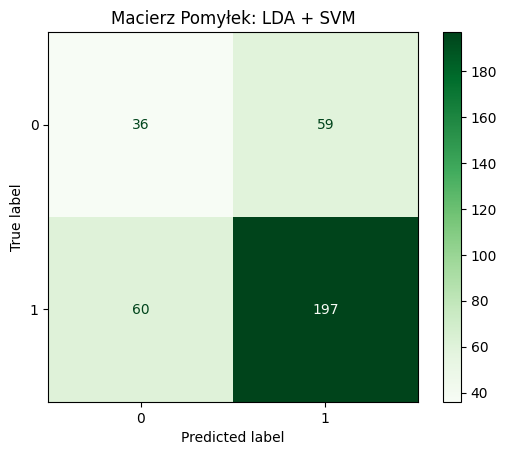

In [47]:
clf = SVC(kernel='rbf', class_weight='balanced')
clf.fit(X_train_lda, y_train)

y_pred = clf.predict(X_test_lda)

acc = accuracy_score(y_test, y_pred)
print(f"Dokładność (LDA + SVM): {acc:.2%}")
print("\nReport Klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=['0', '1']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
disp.plot(cmap='Greens')
plt.title('Macierz Pomyłek: LDA + SVM')
plt.show()

## K-NN

### Przygotowanie danych

In [77]:
X_train = train_images.reshape(len(train_images), -1)
X_test = test_images.reshape(len(test_images), -1)
y_train = train_labels
y_test = test_labels

C:\Users\jakub\Documents\GitHub\Medical Data Analysis\.venv\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Dokładność (LDA + KNN): 42.61%

Report Klasyfikacji:
              precision    recall  f1-score   support

           0       0.29      0.79      0.43        95
           1       0.79      0.29      0.43       257

    accuracy                           0.43       352
   macro avg       0.54      0.54      0.43       352
weighted avg       0.66      0.43      0.43       352



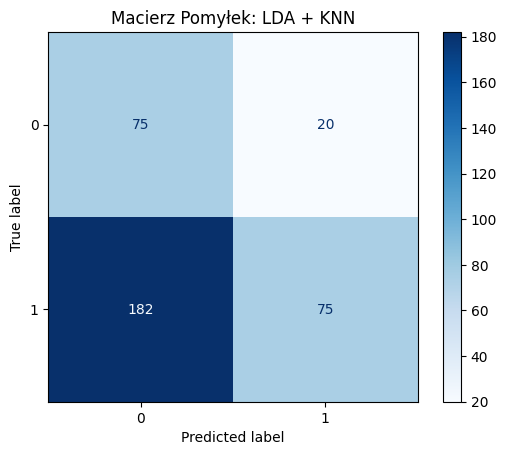

In [79]:
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Dokładność (LDA + KNN): {acc:.2%}")
print("\nReport Klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=['0', '1']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
disp.plot(cmap='Blues')
plt.title('Macierz Pomyłek: LDA + KNN')
plt.show()

### użycie wejścia z LDA

Dokładność (LDA + KNN): 71.02%

Report Klasyfikacji:
              precision    recall  f1-score   support

           0       0.40      0.15      0.22        95
           1       0.74      0.92      0.82       257

    accuracy                           0.71       352
   macro avg       0.57      0.53      0.52       352
weighted avg       0.65      0.71      0.66       352



C:\Users\jakub\Documents\GitHub\Medical Data Analysis\.venv\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


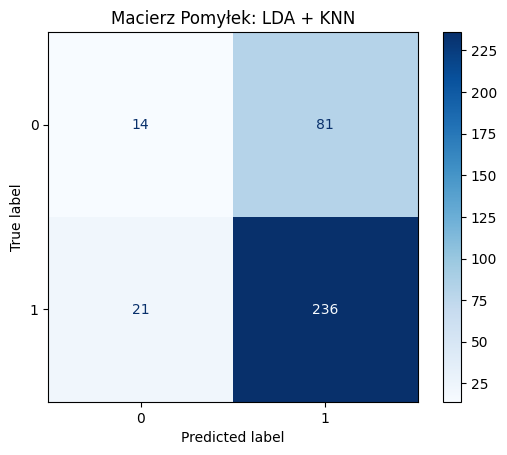

In [80]:
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train_lda, y_train)

y_pred = clf.predict(X_test_lda)

acc = accuracy_score(y_test, y_pred)
print(f"Dokładność (LDA + KNN): {acc:.2%}")
print("\nReport Klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=['0', '1']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
disp.plot(cmap='Blues')
plt.title('Macierz Pomyłek: LDA + KNN')
plt.show()

# To do
Znalezienie klasycznych modeli które pobiją sieć neuronową oraz wprowadzenie resnetu do sieci neuronowej !